# Modelado con Scikit-Learn 

En esta sección se desarrolla el modelo de clasificación mediante una red neuronal
multicapa (MLP) utilizando Scikit-Learn.

Debido al gran tamaño del dataset Avazu, que contiene aproximadamente 40 millones
de registros, no es conveniente utilizar todo el conjunto de datos directamente con
Scikit-Learn. Por esta razón, inicialmente se utiliza **PySpark para cargar y
procesar el dataset**, y posteriormente se selecciona una muestra representativa
de aproximadamente 1 millón de observaciones.

El flujo general del proceso es:

**Dataset completo → PySpark → Muestreo → Pandas → Preprocesamiento → MLP → Evaluación**

El objetivo es construir un modelo capaz de predecir la variable click, donde:

- 0: el usuario no hizo clic en el anuncio.
- 1: el usuario hizo clic en el anuncio.

## Carga de Datos  

En primer lugar, se crea una sesión de PySpark para realizar la lectura del dataset. Esta decisión se toma debido al tamaño considerable de los datos, ya que el conjunto de entrenamiento contiene más de 40 millones de registros. Además, PySpark permite realizar operaciones sobre grandes volúmenes de datos de manera más eficiente que cargar directamente todo el archivo en memoria mediante Pandas. Primeramente, se configuran algunos parámetros de memoria y particionamiento para facilitar el procesamiento local del dataset. Posteriormente, se leen los archivos "train.csv" y "test.csv", utilizando la primera fila como encabezado e intentando inferir automáticamente los tipos de datos de cada variable.

In [4]:
from pyspark.sql import SparkSession

# Carga del Dataset 
spark = SparkSession.builder \
    .appName("Avazu_EDA") \
    .config("spark.driver.memory", "16g") \
    .config("spark.executor.memory", "16g") \
    .config("spark.driver.maxResultSize", "0") \
    .config("spark.sql.shuffle.partitions", "32") \
    .getOrCreate()
df_train = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("../data/train.csv")
df_test = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("../data/test.csv")


## Ingeniería de características temporales

La variable "hour" contiene la fecha y hora de la impresión del anuncio en un formato codificado. Para facilitar su utilización en el modelo, esta variable se transforma en características temporales más interpretables.
Se crean tres nuevas variables:

- day: día del mes correspondiente a la impresión.
- hour_of_day: hora del día en la que ocurrió la impresión.
- franja_horaria: agrupación de la hora en cuatro periodos del día.

La variable franja_horaria clasifica las observaciones de la siguiente manera:

- 00:00–05:59 = Madrugada
- 06:00–11:59 = Mañana
- 12:00–17:59 = Tarde
- 18:00–23:59 = Noche

Esta transformación permite representar la información temporal de una forma más útil para el modelo, ya que la hora puede estar relacionada con el comportamiento del usuario y, por tanto, con la probabilidad de hacer clic en un anuncio.  

Además, las mismas transformaciones realizadas sobre el conjunto de entrenamiento se aplican al conjunto de prueba. Esto es necesario para que ambos conjuntos tengan una estructura equivalente y puedan ser procesados posteriormente por el mismo esquema de preprocesamiento.

In [5]:
import pyspark.sql.functions as F
# 1. Convertir 'hour' a String para extracción de caracteres
df_train_1 = df_train.withColumn("hour_str", F.col("hour").cast("string"))

# 2. Extraer día, hora del día y construir la franja horaria directamente
df_transformed = df_train_1 \
    .withColumn("day", F.substring("hour_str", 5, 2).cast("integer")) \
    .withColumn("hour_of_day", F.substring("hour_str", 7, 2).cast("integer")) \
    .withColumn(
        "franja_horaria",
        F.when((F.col("hour_of_day") >= 0) & (F.col("hour_of_day") < 6), "Madrugada")
         .when((F.col("hour_of_day") >= 6) & (F.col("hour_of_day") < 12), "Mañana")
         .when((F.col("hour_of_day") >= 12) & (F.col("hour_of_day") < 18), "Tarde")
         .otherwise("Noche")
    ) \
    .drop("hour_str")

# Mostrar las columnas seleccionadas
df_transformed.select("hour", "day", "hour_of_day", "franja_horaria").show(5)

# transformación para df_test

df_train_2 = df_test.withColumn("hour_str", F.col("hour").cast("string"))
df_transformed_test = df_train_2 \
    .withColumn("day", F.substring("hour_str", 5, 2).cast("integer")) \
    .withColumn("hour_of_day", F.substring("hour_str", 7, 2).cast("integer")) \
    .withColumn(
        "franja_horaria",
        F.when((F.col("hour_of_day") >= 0) & (F.col("hour_of_day") < 6), "Madrugada")
         .when((F.col("hour_of_day") >= 6) & (F.col("hour_of_day") < 12), "Mañana")
         .when((F.col("hour_of_day") >= 12) & (F.col("hour_of_day") < 18), "Tarde")
         .otherwise("Noche")
    ) \
    .drop("hour_str")

+--------+---+-----------+--------------+
|    hour|day|hour_of_day|franja_horaria|
+--------+---+-----------+--------------+
|14102100| 21|          0|     Madrugada|
|14102100| 21|          0|     Madrugada|
|14102100| 21|          0|     Madrugada|
|14102100| 21|          0|     Madrugada|
|14102100| 21|          0|     Madrugada|
+--------+---+-----------+--------------+
only showing top 5 rows



## Muestreo de los datos  

Debido al tamaño del dataset, el modelado con Scikit-Learn se realiza utilizando una muestra representativa del conjunto de entrenamiento. Dado que, el dataset original contiene aproximadamente 40 millones de registros y se desea mostrar las diferencias entre el entranamiento con esta muestra y todos los datos, de esta forma, se selecciona una muestra de aproximadamente 1 millón de observaciones.

El muestreo se realiza de forma estratificada utilizando la variable objetivo "click", de manera que se conserve aproximadamente la proporción de las clases presente en el conjunto original; y se utiliza una semilla (seed=42) para garantizar que el proceso sea reproducible. Sin embargo, la cantidad final puede no ser exactamente igual a un millón debido a que
sampleBy() realiza un muestreo probabilístico. En este caso se obtuvieron 999.336 observaciones. Una vez seleccionada la muestra, esta se convierte a un DataFrame de Pandas para ser usados con scikit-learn.

In [6]:
total_rows = df_transformed.count()
fraction = 1_000_000 / total_rows

# Muestreo Estratificado por la variable objetivo 'click' en PySpark
# sampleBy toma un diccionario con las proporciones por cada clase (0 y 1)
df_sample_spark = df_transformed.sampleBy("click", fractions={0: fraction, 1: fraction}, seed=42)

# Convertir la muestra reducida de 1M directamente a un DataFrame de Pandas
datos= df_sample_spark.toPandas()

# Verificación
print(f"Total registros originales: {total_rows:,}")
print(f"Total registros en Pandas: {len(datos):,}")
print("\nDistribución de 'click' en la muestra (Pandas):")
print(datos['click'].value_counts(normalize=True))

Total registros originales: 40,428,967
Total registros en Pandas: 999,336

Distribución de 'click' en la muestra (Pandas):
click
0    0.830516
1    0.169484
Name: proportion, dtype: float64


### Información del dataset resultante  

Antes de realizar el modelado, se verifica la estructura del DataFrame obtenido.
Se revisan:

- número de observaciones;
- número de variables;
- tipos de datos;
- cantidad de valores no nulos;
- consumo aproximado de memoria.

Esta revisión permite identificar qué variables son numéricas y cuáles son categóricas, información necesaria para definir posteriormente las técnicas de preprocesamiento.

In [7]:
datos.shape

(999336, 27)

In [8]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999336 entries, 0 to 999335
Data columns (total 27 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                999336 non-null  object
 1   click             999336 non-null  int32 
 2   hour              999336 non-null  int32 
 3   C1                999336 non-null  int32 
 4   banner_pos        999336 non-null  int32 
 5   site_id           999336 non-null  object
 6   site_domain       999336 non-null  object
 7   site_category     999336 non-null  object
 8   app_id            999336 non-null  object
 9   app_domain        999336 non-null  object
 10  app_category      999336 non-null  object
 11  device_id         999336 non-null  object
 12  device_ip         999336 non-null  object
 13  device_model      999336 non-null  object
 14  device_type       999336 non-null  int32 
 15  device_conn_type  999336 non-null  int32 
 16  C14               999336 non-null  int

## Preprocesamiento  

El preprocesamiento tiene como objetivo transformar las variables originales en un formato adecuado para ser utilizado por la red neuronal.
Las principales tareas realizadas son:

1. Selección de variables.
2. División de los datos en entrenamiento y prueba.
3. Reducción de cardinalidad mediante Top-K.
4. Codificación de variables categóricas mediante One-Hot Encoding.
5. Estandarización de variables numéricas.

Estas transformaciones son necesarias porque el MLP de Scikit-Learn requiere variables numéricas y se beneficia de que las variables continuas se encuentren en escalas comparables.

In [9]:
import pandas as pd
import numpy as np
import os
import pickle
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
os.makedirs("../checkpoints", exist_ok=True)

### Selección de variables relevantes  

Se decidió eliminar las variables "id", "hour", "device_ip" y "device_id" por su alta cardinalidad y por ser redundante para el modelo. Además, se definieron las técnicas de preprocesamiento para cada variable: 
- Aplicación de top_k grouping entre 10-50: para las variables "site_id", "site_domain", "app_id", "app_domain", "device_model", "C14"
- Aplicación de top_k grouping entre 10-30: para las variables "C17", "C19", "C20", "C21"
- Aplicación de One_Hot_encoder: para las variables "C1", "banner_pos", "site_category", "app_category","device_type", "device_conn_type", "C15", "C16","C18", "franja_horaria"

In [10]:

cols_drop = ["id", "hour", "device_ip", "device_id"] 

cols_topk_high = ["site_id", "site_domain", "app_id", "app_domain",
                   "device_model", "C14"]        # K entre 10-50

cols_topk_medium = ["C17", "C19", "C20", "C21"]  # K entre 10-30

cols_onehot_direct = ["C1", "banner_pos", "site_category", "app_category",
                       "device_type", "device_conn_type", "C15", "C16",
                       "C18", "franja_horaria"]

cols_numeric = ["day", "hour_of_day"]
target = "click"

df_model = datos.drop(columns=cols_drop).copy()

### Division de train/test estratificada 

Después de seleccionar las variables, se separan las características predictoras "X" de la variable objetivo "y". La variable objetivo es "click", que representa si ocurrió o no un clic sobre el anuncio. Los datos se dividen utilizando una proporción de 80 % para entrenamiento y 20 % para prueba. Además, se utiliza "stratify=y" para realizar una división estratificada. Esto permite conservar aproximadamente la misma proporción de las clases `0` y `1` en ambos conjuntos.
La estratificación es especialmente importante en problemas de clasificación, ya que evita que el conjunto de prueba tenga una distribución de clases muy diferente a la del conjunto de entrenamiento.

In [11]:
X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("\nProporción de clases (train):")
print(y_train.value_counts(normalize=True))
print("\nProporción de clases (test):")
print(y_test.value_counts(normalize=True))

Train: (799468, 22) | Test: (199868, 22)

Proporción de clases (train):
click
0    0.830516
1    0.169484
Name: proportion, dtype: float64

Proporción de clases (test):
click
0    0.830518
1    0.169482
Name: proportion, dtype: float64


In [12]:
X_train.shape

(799468, 22)

### Codificación + escalado  

Algunas variables categóricas presentan una gran cantidad de categorías diferentes. Aplicar One-Hot Encoding directamente sobre ellas podría generar cientos o miles de columnas y aumentar considerablemente el costo computacional del modelo. Por tanto, para solucionar este problema se utiliza la estrategia Top-K Grouping, esta técnica conserva las categorías que aparecen con mayor frecuencia y agrupa todas las demás categorías bajo una única categoría denominada `Otros`. Para las variables de mayor cardinalidad se conservan las 30 categorías más frecuentes, mientras que para las variables de cardinalidad media se conservan las 20 categorías más frecuentes. De esta manera se reduce la dimensionalidad de los datos y se facilita el
entrenamiento de la red neuronal.

Además, el Top-K se calcula utilizando exclusivamente el conjunto de entrenamiento. Esto significa que las categorías más frecuentes se determinan a partir de `X_train` y posteriormente esas mismas categorías se aplican tanto a `X_train` como a `X_test`. Esta estrategia evita el **data leakage**, ya que ninguna información del conjunto de prueba participa en el aprendizaje del preprocesamiento.

El flujo utilizado es:

**X_train → aprender categorías Top-K → transformar X_train y X_test**

In [ ]:
def ajustar_topk_grouping(df_train, columnas, k_dict, categoria_otros="Otros"):
    """Calcula las categorías top-k usando SOLO datos de entrenamiento."""
    top_categorias = {}
    for col in columnas:
        k = k_dict[col]
        # Aseguramos tipo string ANTES de calcular frecuencias
        serie = df_train[col].astype(str)
        top_k = serie.value_counts().nlargest(k).index
        top_categorias[col] = set(top_k)
    return top_categorias

def aplicar_topk_grouping(df, top_categorias, categoria_otros="Otros"):
    """Aplica categorías ya calculadas a cualquier partición (train, test, o test real de Kaggle)."""
    df = df.copy()
    for col, top_k in top_categorias.items():
        df[col] = df[col].astype(str)  # uniformar tipo primero
        df[col] = df[col].where(df[col].isin(top_k), categoria_otros)
    return df

k_dict = {**{c: 30 for c in cols_topk_high}, **{c: 20 for c in cols_topk_medium}}
cols_topk_all = cols_topk_high + cols_topk_medium

# Fit SOLO en train
top_categorias_guardadas = ajustar_topk_grouping(X_train, cols_topk_all, k_dict)

# Transform en train y en test (test usa las categorías aprendidas en train)
X_train = aplicar_topk_grouping(X_train, top_categorias_guardadas)
X_test = aplicar_topk_grouping(X_test, top_categorias_guardadas)

print("\nProporción de clases (train):")
print(y_train.value_counts(normalize=True))
print("\nProporción de clases (test):")
print(y_test.value_counts(normalize=True))


# Codificación de categóricas + Escalado de numéricas
cols_categoricas = cols_topk_all + cols_onehot_direct  # topk_high + topk_medium + onehot_direct

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cols_categoricas),
        ("num", StandardScaler(), cols_numeric),
    ],
    remainder="drop"
)

# Fit SOLO en train
X_train_proc = preprocessor.fit_transform(X_train)

# Transform (no fit) en test
X_test_proc = preprocessor.transform(X_test)

print("Dimensión final del vector de entrada:", X_train_proc.shape[1])
print("X_train_proc:", X_train_proc.shape, "| X_test_proc:", X_test_proc.shape)


Proporción de clases (train):
click
0    0.830516
1    0.169484
Name: proportion, dtype: float64

Proporción de clases (test):
click
0    0.830518
1    0.169482
Name: proportion, dtype: float64
Dimensión final del vector de entrada: 370
X_train_proc: (799468, 370) | X_test_proc: (199868, 370)


## Definición del entrenamiento  

En este bloque se establece el proceso mediante el cual se entrenan y evalúan diferentes configuraciones del modelo MLP (Multi-Layer Perceptron). Para ello, se define una búsqueda sistemática de hiperparámetros con el objetivo de identificar la configuración que presenta el mejor desempeño.

Primero se establece una grilla de hiperparámetros que contiene diferentes combinaciones de:

Arquitectura de la red (hidden_layer_sizes): se prueban las configuraciones $(50,)$, $(100,)$ y $(100,50)$, que representan una o dos capas ocultas con diferente número de neuronas.
Regularización (alpha): se consideran los valores $0.0001$, $0.001$ y $0.01$, con el propósito de controlar la complejidad del modelo y reducir el riesgo de sobreajuste.
Número máximo de iteraciones (max_iter): se prueban los valores $50$ y $100$.

En total, se generan:

$$
3 \times 3 \times 2 = 18
$$

combinaciones de hiperparámetros.

### **Proceso de entrenamiento**

Para cada una de las combinaciones generadas, se realiza el siguiente procedimiento:

Se verifica si la combinación ya fue evaluada anteriormente mediante el archivo de resultados almacenado como checkpoint. Si ya existe, se omite para evitar repetir el entrenamiento.
Se crea un nuevo MLPClassifier utilizando la configuración correspondiente. Se utiliza random_state=42 para garantizar la reproducibilidad del proceso y early_stopping=True para permitir que el entrenamiento se detenga anticipadamente cuando el modelo deje de mejorar.
Se entrena el modelo utilizando los datos previamente transformados (X_train_proc) y las etiquetas de entrenamiento (y_train). Durante este proceso se registra el tiempo de entrenamiento.
Una vez entrenado, el modelo realiza predicciones sobre el conjunto de prueba (X_test_proc). Se obtienen tanto las clases predichas como las probabilidades de pertenencia a la clase positiva.
A partir de estas predicciones se calculan las métricas Accuracy, Precision, Recall, F1-Score y ROC AUC, además de la matriz de confusión.
También se registra el tiempo de predicción, lo que permitirá posteriormente analizar el costo computacional del modelo.
Finalmente, se guarda el modelo entrenado, la matriz de confusión y los resultados obtenidos. El archivo CSV se actualiza después de cada iteración, funcionando como un checkpoint que permite conservar el progreso de la búsqueda.

De esta manera, el proceso completo para cada configuración puede representarse como:

$$
\text{Configuración}
\rightarrow
\text{Entrenamiento}
\rightarrow
\text{Predicción}
\rightarrow
\text{Evaluación}
\rightarrow
\text{Medición del tiempo}
\rightarrow
\text{Almacenamiento}
$$

Al finalizar todas las combinaciones, se obtiene un conjunto de resultados que permite comparar el desempeño de las diferentes configuraciones del MLP y seleccionar posteriormente la más adecuada según las métricas obtenidas.

In [14]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix)
import time

param_grid = {
    "hidden_layer_sizes": [(50,), (100,), (100, 50)],
    "alpha": [0.0001, 0.001, 0.01],
    "max_iter": [50, 100],
}

checkpoint_dir = "../checkpoints/mlp_gridsearch"
os.makedirs(checkpoint_dir, exist_ok=True)
results_path = os.path.join(checkpoint_dir, "resultados_gridsearch.csv")

# Si ya hay resultados previos, se cargan para no repetir combinaciones
if os.path.exists(results_path):
    resultados_df = pd.read_csv(results_path)
    combinaciones_evaluadas = set(
        zip(resultados_df["hidden_layer_sizes"], resultados_df["alpha"], resultados_df["max_iter"])
    )
else:
    resultados_df = pd.DataFrame(columns=[
        "iteracion", "hidden_layer_sizes", "alpha", "max_iter",
        "accuracy", "precision", "recall", "f1_score", "roc_auc",
        "train_time_seg", "predict_time_seg", "modelo_path"
    ])
    combinaciones_evaluadas = set()

grid = list(ParameterGrid(param_grid))
print(f"Total de combinaciones a evaluar: {len(grid)}")

for i, params in enumerate(grid, start=1):
    combo_key = (str(params["hidden_layer_sizes"]), params["alpha"], params["max_iter"])
    if combo_key in combinaciones_evaluadas:
        print(f"[{i}/{len(grid)}] Ya evaluado, se omite: {params}")
        continue

    print(f"[{i}/{len(grid)}] Entrenando con: {params}")

    modelo = MLPClassifier(
        hidden_layer_sizes=params["hidden_layer_sizes"],
        alpha=params["alpha"],
        max_iter=params["max_iter"],
        random_state=42,
        early_stopping=True,
    )

    t0 = time.time()
    modelo.fit(X_train_proc, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = modelo.predict(X_test_proc)
    y_proba = modelo.predict_proba(X_test_proc)[:, 1]
    predict_time = time.time() - t0

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    modelo_filename = f"mlp_iter{i}.pkl"
    modelo_path = os.path.join(checkpoint_dir, modelo_filename)
    joblib.dump(modelo, modelo_path)
    np.save(os.path.join(checkpoint_dir, f"cm_iter{i}.npy"), cm)

    nueva_fila = {
        "iteracion": i,
        "hidden_layer_sizes": str(params["hidden_layer_sizes"]),
        "alpha": params["alpha"],
        "max_iter": params["max_iter"],
        "accuracy": acc, "precision": prec, "recall": rec,
        "f1_score": f1, "roc_auc": auc,
        "train_time_seg": train_time, "predict_time_seg": predict_time,
        "modelo_path": modelo_path,
    }
    resultados_df = pd.concat([resultados_df, pd.DataFrame([nueva_fila])], ignore_index=True)

    # Checkpoint: se guarda el CSV acumulado tras CADA iteración
    resultados_df.to_csv(results_path, index=False)

    print(f"   -> AUC: {auc:.4f} | F1: {f1:.4f} | Recall: {rec:.4f} | "
          f"Train: {train_time:.1f}s | Predict: {predict_time:.2f}s")

print("\nBúsqueda completada.")

Total de combinaciones a evaluar: 18
[1/18] Ya evaluado, se omite: {'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'max_iter': 50}
[2/18] Entrenando con: {'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'max_iter': 100}
   -> AUC: 0.7331 | F1: 0.1286 | Recall: 0.0725 | Train: 94.8s | Predict: 0.31s
[3/18] Entrenando con: {'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'max_iter': 50}
   -> AUC: 0.7340 | F1: 0.1290 | Recall: 0.0727 | Train: 89.1s | Predict: 0.41s
[4/18] Entrenando con: {'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'max_iter': 100}
   -> AUC: 0.7340 | F1: 0.1290 | Recall: 0.0727 | Train: 86.6s | Predict: 0.39s
[5/18] Entrenando con: {'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'max_iter': 50}
   -> AUC: 0.7346 | F1: 0.1181 | Recall: 0.0657 | Train: 106.8s | Predict: 0.46s
[6/18] Entrenando con: {'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'max_iter': 100}
   -> AUC: 0.7346 | F1: 0.1181 | Recall: 0.0657 | Train: 105.5s | Predict: 0.46s
[7/18] Entrenando con: {'

## Tabla de resultados del entrenamiento  

In [15]:
resultados_df = resultados_df.sort_values("roc_auc", ascending=False)
display(resultados_df.head(10))

mejor_fila = resultados_df.iloc[0]
mejor_modelo = joblib.load(mejor_fila["modelo_path"])

print("Mejor combinación de hiperparámetros:")
print(mejor_fila[["hidden_layer_sizes", "alpha", "max_iter", "roc_auc", "f1_score", "recall"]])

,iteracion,hidden_layer_sizes,alpha,max_iter,accuracy,precision,recall,f1_score,roc_auc,train_time_seg,predict_time_seg,modelo_path
4,5,"(100, 50)",0.0001,50,0.833680,0.582723,0.065714,0.118109,0.734623,106.770765,0.455750,../checkpoints/mlp_gridsearch\mlp_iter5.pkl
5,6,"(100, 50)",0.0001,100,0.833680,0.582723,0.065714,0.118109,0.734623,105.496664,0.459673,../checkpoints/mlp_gridsearch\mlp_iter6.pkl
2,3,"(100,)",0.0001,50,0.833695,0.574061,0.072652,0.128980,0.733972,89.112804,0.411225,../checkpoints/mlp_gridsearch\mlp_iter3.pkl
3,4,"(100,)",0.0001,100,0.833695,0.574061,0.072652,0.128980,0.733972,86.555765,0.390865,../checkpoints/mlp_gridsearch\mlp_iter4.pkl
9,10,"(100,)",0.0010,100,0.833735,0.579599,0.069109,0.123493,0.733957,72.227220,0.387910,../checkpoints/mlp_gridsearch\mlp_iter10.pkl
8,9,"(100,)",0.0010,50,0.833735,0.579599,0.069109,0.123493,0.733957,71.729862,0.406160,../checkpoints/mlp_gridsearch\mlp_iter9.pkl
10,11,"(100, 50)",0.0010,50,0.833820,0.589967,0.063884,0.115284,0.733841,70.638867,0.448594,../checkpoints/mlp_gridsearch\mlp_iter11.pkl
11,12,"(100, 50)",0.0010,100,0.833820,0.589967,0.063884,0.115284,0.733841,72.537413,0.453664,../checkpoints/mlp_gridsearch\mlp_iter12.pkl
6,7,"(50,)",0.0010,50,0.833605,0.578799,0.066895,0.119929,0.733708,104.049732,0.300331,../checkpoints/mlp_gridsearch\mlp_iter7.pkl
7,8,"(50,)",0.0010,100,0.833605,0.578799,0.066895,0.119929,0.733708,104.330171,0.312123,../checkpoints/mlp_gridsearch\mlp_iter8.pkl


Mejor combinación de hiperparámetros:
hidden_layer_sizes    (100, 50)
alpha                    0.0001
max_iter                     50
roc_auc                0.734623
f1_score               0.118109
recall                 0.065714
Name: 4, dtype: object


Resultados de la búsqueda de hiperparámetros

Se evaluaron diferentes configuraciones del MLP utilizando Accuracy, Precision, Recall, F1-Score y ROC AUC, además del tiempo de entrenamiento y predicción.

La mejor configuración fue:
Capas ocultas: (100, 50)
Alpha: 0.0001
Max_iter: 50
ROC AUC: 0.7346
F1-Score: 0.1181
Recall: 0.0657

La selección se realizó tomando ROC AUC como criterio principal. Aunque la Accuracy fue de 83.37%, el Recall fue bajo, lo que refleja la dificultad del modelo para identificar correctamente la clase positiva debido al desbalance de los datos.

In [16]:
import json

# Carpeta de modelos finales (distinta de los checkpoints de cada iteración)
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

mejor_modelo_path = os.path.join(models_dir, "mlp_sklearn_mejor_modelo.pkl")
joblib.dump(mejor_modelo, mejor_modelo_path)

# Guardar también el preprocesador, para poder aplicar el modelo a datos nuevos
preprocessor_path = os.path.join(models_dir, "preprocessor_sklearn.pkl")
joblib.dump(preprocessor, preprocessor_path)

# Info de hiperparámetros y métricas del mejor modelo
info_path = os.path.join(models_dir, "mlp_sklearn_mejor_modelo_info.json")
with open(info_path, "w") as f:
    json.dump(mejor_fila.to_dict(), f, indent=2, default=str)

print(f"Modelo guardado en: {mejor_modelo_path}")
print(f"Preprocesador guardado en: {preprocessor_path}")
print(f"Info guardada en: {info_path}")

Modelo guardado en: ../models\mlp_sklearn_mejor_modelo.pkl
Preprocesador guardado en: ../models\preprocessor_sklearn.pkl
Info guardada en: ../models\mlp_sklearn_mejor_modelo_info.json


Finalmente, en el bloque anterior se guarda el mejor modelo.   

## Matriz de confusión  

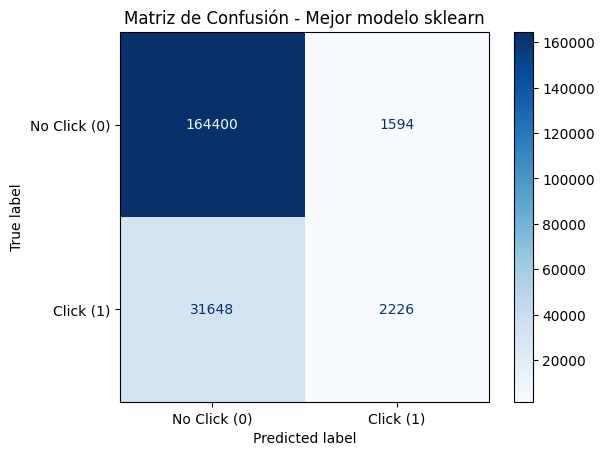

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

checkpoint_dir = "../checkpoints/mlp_gridsearch"
results_path = os.path.join(checkpoint_dir, "resultados_gridsearch.csv")

resultados_df = pd.read_csv(results_path)
resultados_df = resultados_df.sort_values("roc_auc", ascending=False)

mejor_fila = resultados_df.iloc[0]
mejor_iteracion = int(mejor_fila["iteracion"])

cm_path = os.path.join(checkpoint_dir, f"cm_iter{mejor_iteracion}.npy")
cm = np.load(cm_path)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Click (0)", "Click (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Matriz de Confusión - Mejor modelo sklearn")
plt.show()

La matriz de confusión muestra que el modelo predice correctamente la mayoría de los casos sin click, pero identifica muy pocos clics reales: de los 33,874 clics presentes en el conjunto de prueba, solo detectó 2,226, dejando pasar la gran mayoría como falsos negativos. Esto refleja el desbalance del dataset y el umbral de decisión fijo (0.5), que favorecen a la clase mayoritaria. Por eso, aunque la exactitud global parece buena, no es una métrica confiable aquí: un modelo que siempre predijera "No Click" obtendría un resultado similar sin aportar ningún valor real para identificar clics.   

## Curva ROC  

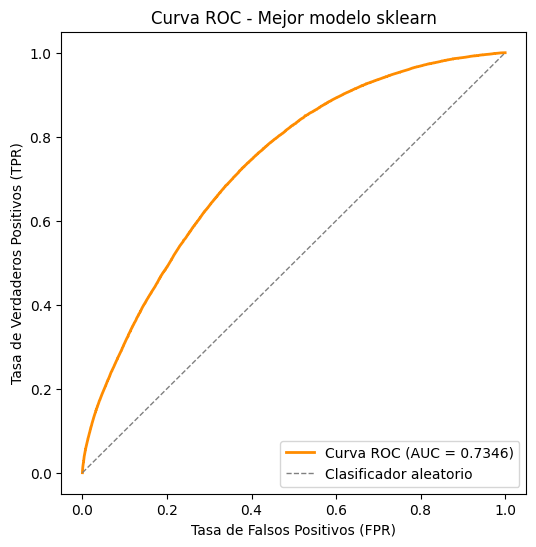

In [ ]:
import joblib
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


mejor_modelo = joblib.load("../checkpoints/mlp_gridsearch/mlp_iter5.pkl")

y_proba = mejor_modelo.predict_proba(X_test_proc)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc_value = auc(fpr, tpr)

# Graficar
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"Curva ROC (AUC = {roc_auc_value:.4f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Clasificador aleatorio")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC - Mejor modelo sklearn")
plt.legend(loc="lower right")
plt.show()

La curva ROC del mejor modelo en la iteración 5 alcanza un AUC de 0.7346, ubicándose claramente por encima de la diagonal de referencia (clasificador aleatorio, AUC=0.5), lo que indica una capacidad de discriminación moderada entre clics y no clics. Se optó por graficar únicamente la curva del mejor modelo, y no las de las 18 combinaciones del grid search, porque la tabla de resultados ya resume cuantitativamente el desempeño de cada una (AUC, F1, recall); dado que varias combinaciones arrojaron valores prácticamente idénticos.  

## Interpretabilidad con LIME

In [ ]:
import lime
import lime.lime_tabular
import numpy as np

nombres_features = preprocessor.get_feature_names_out()

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_proc,
    feature_names=nombres_features,
    class_names=["No Click", "Click"],
    mode="classification"
)

In [ ]:
y_pred = mejor_modelo.predict(X_test_proc)
y_test_reset = y_test.reset_index(drop=True)

# Un Falso Negativo
idx_falso_negativo = np.where((y_pred == 0) & (y_test_reset == 1))[0][0]

# Un Falso Positivo
idx_falso_positivo = np.where((y_pred == 1) & (y_test_reset == 0))[0][0]

print(f"Índice del Falso Negativo elegido: {idx_falso_negativo}")
print(f"Índice del Falso Positivo elegido: {idx_falso_positivo}")

Índice del Falso Negativo elegido: 11
Índice del Falso Positivo elegido: 19


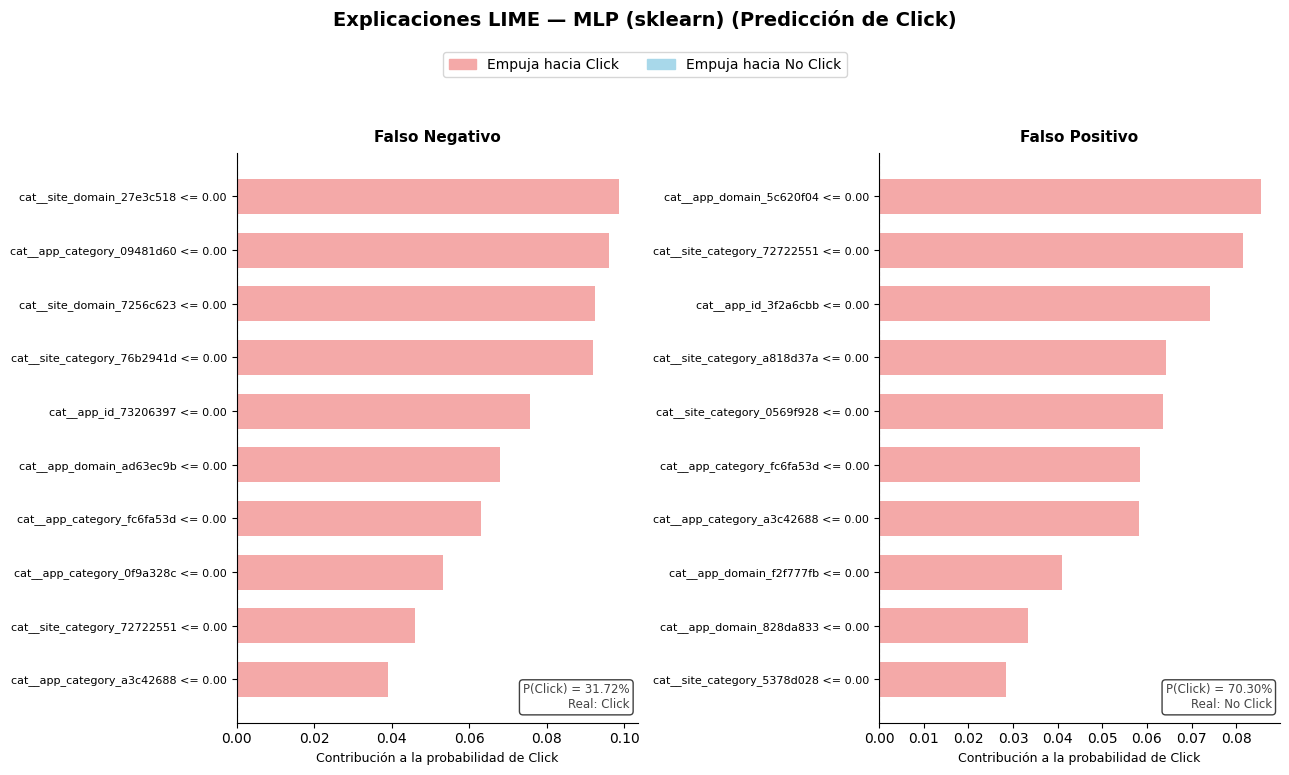

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Colores pastel
COLOR_CLICK    = "#F4A9A8"  # empuja hacia "Click"
COLOR_NO_CLICK = "#A8D8EA"  # empuja hacia "No Click"

MODEL_NAME = "MLP (sklearn)"

y_test_reset = y_test.reset_index(drop=True)
y_pred = mejor_modelo.predict(X_test_proc)
y_prob = mejor_modelo.predict_proba(X_test_proc)[:, 1]

# Solo los 2 casos que pide el enunciado: instancias mal clasificadas
idx_falso_negativo = np.where((y_pred == 0) & (y_test_reset == 1))[0][0]
idx_falso_positivo = np.where((y_pred == 1) & (y_test_reset == 0))[0][0]

casos = {
    "Falso Negativo": idx_falso_negativo,
    "Falso Positivo": idx_falso_positivo,
}

def plot_lime(idx, titulo, ax, n_features=10):
    instancia = X_test_proc[idx]

    exp = explainer.explain_instance(
        data_row     = instancia,
        predict_fn   = mejor_modelo.predict_proba,
        num_features = n_features,
        num_samples  = 5000,
        labels       = [0, 1],
    )

    label_disponible = 1 if 1 in exp.local_exp else list(exp.local_exp.keys())[0]
    pesos = exp.as_list(label=label_disponible)

    labels  = [f for f, _ in pesos]
    weights = [w for _, w in pesos]
    colors  = [COLOR_CLICK if w > 0 else COLOR_NO_CLICK for w in weights]

    orden   = np.argsort(np.abs(weights))
    labels  = [labels[i]  for i in orden]
    weights = [weights[i] for i in orden]
    colors  = [colors[i]  for i in orden]

    ax.barh(labels, weights, color=colors, edgecolor="none", height=0.65)
    ax.axvline(0, color="#aaa", linewidth=0.8, linestyle="--")
    ax.set_title(titulo, fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Contribución a la probabilidad de Click", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="y", labelsize=8)

    real = "Click" if y_test_reset[idx] == 1 else "No Click"
    ax.text(0.98, 0.02,
            f"P(Click) = {y_prob[idx]:.2%}\nReal: {real}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=8.5, color="#444",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.75))

fig, axes = plt.subplots(1, 2, figsize=(13, 7))

for ax, (titulo, idx) in zip(axes, casos.items()):
    plot_lime(idx, titulo, ax)

patch_push    = mpatches.Patch(color=COLOR_CLICK,    label="Empuja hacia Click")
patch_protect = mpatches.Patch(color=COLOR_NO_CLICK, label="Empuja hacia No Click")
fig.legend(handles=[patch_push, patch_protect],
           loc="upper center", ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, 1.05), framealpha=0.8)

fig.suptitle(
    f"Explicaciones LIME — {MODEL_NAME} (Predicción de Click)",
    fontsize=14, fontweight="bold", y=1.1
)
plt.tight_layout()
plt.savefig("../data/lime_explanations.png", dpi=150, bbox_inches="tight")
plt.show()

Las explicaciones LIME para las dos instancias mal clasificadas muestran que el modelo se apoya mayoritariamente en variables relacionadas con 'site_domain', 'app_domain', 'app_category', 'site_category' y 'app_id' para tomar su decisión, lo que confirma que el contexto de la app o sitio donde se muestra el anuncio es el factor más determinante en la predicción. En el falso negativo, aunque las diez variables más influyentes empujan hacia "Click", su efecto combinado solo alcanza una probabilidad de 31.72%, insuficiente para superar el umbral de 0.5 y detectar el click real. En el falso positivo ocurre lo inverso: las mismas variables generan una probabilidad alta (70.30%) sin que el click ocurriera realmente, lo que sugiere que ciertas combinaciones de categorías pueden sobreestimar el interés del usuario incluso cuando no se materializa en un click. En ambos casos, las variables identificadas por LIME son consistentes con las señales contextuales esperadas del dominio del problema, aunque el modelo aún tiene dificultad para calibrar correctamente la magnitud de su confianza.

In [ ]:
import numpy as np
import joblib
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


mejor_modelo = joblib.load("../checkpoints/mlp_gridsearch/mlp_iter5.pkl")

y_proba = mejor_modelo.predict_proba(X_test_proc)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)  # y_proba ya lo tenías de la celda de la curva ROC
roc_auc_sklearn = auc(fpr, tpr)

np.savez("../models/roc_curve_sklearn.npz", fpr=fpr, tpr=tpr, auc=roc_auc_sklearn)
print("Curva ROC de sklearn guardada.")

Curva ROC de sklearn guardada.
